# Noise vs RF Separability

Two experiments that share the same RF discriminator but ask different questions:

**Test 1 — Fixed-sigma sweep.** For each generator, sweep noise level sigma and measure real-vs-synthetic separability. Output: one curve per generator per dataset.

**Test 2 — Target-AUC search.** For each generator, binary-search sigma to hit a target separability. Report iterations, final sigma, and whether the search converged.

Both tests use `RFWrapper.from_combined` as the discriminator (5x stratified split, AUC averaged), and corrected separability = `max(AUC, 1 - AUC)` so the metric is symmetric around 0.5.

Generators tested: bootstrap, IID column-wise, GMM, CVAE.

In [12]:
import warnings
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

repo_root = Path.cwd().parent if Path.cwd().name == 'rfhack' else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.loaders import load_HIV, load_breast, load_diabetes
from rfhack.core.rf_wrapper import RFWrapper
from rfhack.core.metrics import stratified_subsample
from rfhack.core.adversarial_hacker_ import AdversarialHacker

from models.bootstrap import sample_bootstrap
from models.iid_columnwise import sample_columnwise
from models.gmm import sample_gmm
from models.cvae import train_cvae, sample_trained_cvae
from util.config import Config
warnings.filterwarnings('ignore')
SEED = 42
FRAC = 0.3
DATASETS = {'HIV': load_HIV, 'Breast Cancer': load_breast, 'Diabetes': load_diabetes}
METHODS = ['Bootstrap', 'IID', 'GMM', 'CVAE']
PROBE_SIGMAS = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0, 1.5, 2.0]
N_REP = 5
TARGET_SEP = 0.7
MAX_ITER = 20
TOL = 0.01
CVAE_EPOCHS = 200

METHOD_COLORS = {
    'Bootstrap': '#4878CF',
    'IID': '#9467BD',
    'GMM': '#F28E2B',
    'CVAE': '#59A14F',
}

def corrected(auc):
    return max(auc, 1.0 - auc)

## Setup: subsamples + generator factories

Build a stratified subsample per dataset and a dict of generator callables `gen_fn(seed) -> (X_syn, y_syn)`. CVAE is trained once per dataset; the others are stateless.

In [13]:
subsamples = {}
generators = {}

for ds_name, loader in DATASETS.items():
    data = loader()
    X, y = data['X'], data['y']
    n0 = max(2, int((y == 0).sum() * FRAC))
    n1 = max(2, int((y == 1).sum() * FRAC))
    X_sub, y_sub, _ = stratified_subsample(X, y, n0=n0, n1=n1, seed=SEED)
    subsamples[ds_name] = (X_sub, y_sub, n0, n1)

    print(f'Training CVAE on {ds_name} (n={len(y_sub)}, p={X_sub.shape[1]})...')
    cvae_cfg = Config(seed=SEED, epochs=CVAE_EPOCHS, batch_size=32)
    cvae_state = train_cvae(X_sub, y_sub, cfg=cvae_cfg)

    generators[ds_name] = {
        'Bootstrap': (lambda s, X=X_sub, y=y_sub, n0=n0, n1=n1:
                      sample_bootstrap(X, y, n0, n1, seed=s)),
        'IID':       (lambda s, X=X_sub, y=y_sub, n0=n0, n1=n1:
                      sample_columnwise(X, y, n0, n1, seed=s)),
        'GMM':       (lambda s, X=X_sub, y=y_sub, n0=n0, n1=n1:
                      sample_gmm(X, y, n0, n1, seed=s)),
        'CVAE':      (lambda s, state=cvae_state, n0=n0, n1=n1:
                      sample_trained_cvae(state, n0, n1, seed=s)),
    }

print('Setup complete.')

Training CVAE on HIV (n=26, p=63)...
Epoch    1 | train loss=63.2365 recon=63.1818 kl=0.1094 | val loss=317.2227 recon=316.9922 kl=0.4611
Epoch   10 | train loss=63.7294 recon=63.6127 kl=0.2335 | val loss=315.2209 recon=314.7815 kl=0.8789
Epoch   20 | train loss=60.6576 recon=60.1051 kl=1.1050 | val loss=308.9820 recon=306.8816 kl=4.2009
Epoch   30 | train loss=47.1410 recon=42.1090 kl=10.0639 | val loss=251.4183 recon=230.0850 kl=42.6665
Epoch   40 | train loss=38.4663 recon=35.5586 kl=5.8153 | val loss=229.5078 recon=221.8047 kl=15.4061
Epoch   50 | train loss=33.8784 recon=30.2651 kl=7.2266 | val loss=208.5113 recon=199.5646 kl=17.8935
Epoch   60 | train loss=28.6252 recon=24.5142 kl=8.2221 | val loss=208.4792 recon=200.3208 kl=16.3167
Epoch   70 | train loss=26.1256 recon=22.1555 kl=7.9403 | val loss=210.7761 recon=203.3574 kl=14.8373
Epoch   80 | train loss=23.9270 recon=19.2816 kl=9.2909 | val loss=206.5950 recon=197.8382 kl=17.5138
Epoch   90 | train loss=21.4843 recon=16.5440 k

## Test 1 - Fixed-sigma sweep

For each (dataset x method x sigma), draw `N_REP` synthetic datasets, add Gaussian noise scaled by per-feature std, and measure RF separability against real. Plot mean separability vs sigma.

In [14]:
sweep_rows = []

for ds_name, gen_fns in generators.items():
    X_sub, y_sub, _, _ = subsamples[ds_name]
    stds = X_sub.astype(np.float64).std(axis=0)
    stds = np.where(stds == 0, 1.0, stds)
    feat_cols = [f'f{i}' for i in range(X_sub.shape[1])]

    for method, gen_fn in gen_fns.items():
        for sigma in PROBE_SIGMAS:
            seps = []
            for r in range(N_REP):
                rep_seed = SEED + r
                X_syn, _ = gen_fn(rep_seed)
                X_syn = X_syn.astype(np.float64)
                if sigma > 0:
                    rng = np.random.default_rng(rep_seed + 500)
                    X_syn = X_syn + rng.standard_normal(X_syn.shape) * stds * sigma

                real_df = pd.DataFrame(X_sub.astype(np.float64), columns=feat_cols)
                real_df['target'] = 1
                syn_df = pd.DataFrame(X_syn, columns=feat_cols)
                syn_df['target'] = 0
                combined = pd.concat([real_df, syn_df], ignore_index=True)
                avg, _, _ = RFWrapper.from_combined(combined)
                seps.append(corrected(avg))

            sweep_rows.append({
                'dataset':  ds_name,
                'method':   method,
                'sigma':    sigma,
                'sep_mean': float(np.mean(seps)),
                'sep_std':  float(np.std(seps)),
            })
        print(f'{ds_name:<10} {method:<10} done')

sweep_df = pd.DataFrame(sweep_rows)
sweep_df.head()

HIV        Bootstrap  done
HIV        IID        done
HIV        GMM        done
HIV        CVAE       done
Breast Cancer Bootstrap  done
Breast Cancer IID        done
Breast Cancer GMM        done
Breast Cancer CVAE       done
Diabetes   Bootstrap  done
Diabetes   IID        done
Diabetes   GMM        done
Diabetes   CVAE       done


,dataset,method,sigma,sep_mean,sep_std
0,HIV,Bootstrap,0.00,0.711875,0.053729
1,HIV,Bootstrap,0.05,0.650156,0.043037
2,HIV,Bootstrap,0.10,0.616875,0.042044
3,HIV,Bootstrap,0.20,0.550469,0.023689
4,HIV,Bootstrap,0.30,0.627500,0.062606


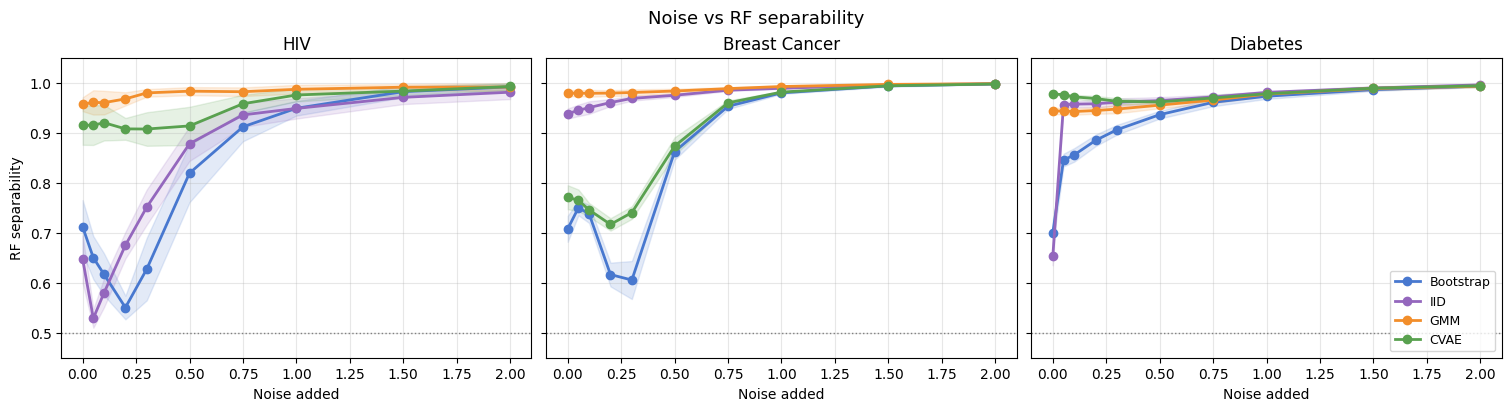

In [18]:
fig, axes = plt.subplots(1, len(DATASETS), figsize=(5 * len(DATASETS), 4),
                          constrained_layout=True, sharey=True)

for ax, ds_name in zip(axes, DATASETS):
    sub = sweep_df[sweep_df['dataset'] == ds_name]
    for method in METHODS:
        m = sub[sub['method'] == method].sort_values('sigma')
        color = METHOD_COLORS[method]
        ax.plot(m['sigma'], m['sep_mean'], 'o-',
                color=color, lw=2, label=method)
        ax.fill_between(m['sigma'],
                         m['sep_mean'] - m['sep_std'],
                         m['sep_mean'] + m['sep_std'],
                         color=color, alpha=0.15)
    ax.axhline(0.5, color='gray', ls=':', lw=1)
    ax.set_title(ds_name)
    ax.set_xlabel('Noise added')
    ax.set_ylim(0.45, 1.05)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('RF separability')
axes[-1].legend(loc='lower right', fontsize=9)
fig.suptitle('Noise vs RF separability', fontsize=13)
plt.show()

## Test 2 - Target-AUC search

For each (dataset x method), `AdversarialHacker.hack(TARGET_SEP)` binary-searches sigma in [0, sigma_max] for `MAX_ITER` steps. Report:
- **converged** — did `|sep - target| < tol` ever hold?
- **iterations** — how many bisection steps until convergence (or `MAX_ITER` if not)
- **final sigma / sep** — best (closest to target) point seen

**Reading the result:** generators that start already above the target (e.g. GMM, CVAE on most datasets) cannot be made *less* detectable by adding noise — adding noise drifts further from real, separability only goes up. The search will fail to converge and final sigma will trend toward 0 (the closest-to-target point on a monotone curve).

In [16]:
search_rows = []

for ds_name, gen_fns in generators.items():
    X_sub, _, _, _ = subsamples[ds_name]
    for method, gen_fn in gen_fns.items():
        hacker = AdversarialHacker(X_sub, gen_fn,
                                    tol=TOL, max_iter=MAX_ITER, seed=SEED)
        result = hacker.hack(TARGET_SEP)
        search_rows.append({
            'dataset':     ds_name,
            'method':      method,
            'converged':   result.converged,
            'iterations':  result.iterations,
            'final_sigma': result.sigma,
            'final_sep':   result.sep,
        })
        flag = 'OK ' if result.converged else 'NO '
        print(f'{ds_name:<10} {method:<10} {flag} '
              f'iters={result.iterations:<3} '
              f'sigma={result.sigma:.3f}  sep={result.sep:.3f}')

search_df = pd.DataFrame(search_rows)
search_df

HIV        Bootstrap  OK  iters=13  sigma=0.385  sep=0.697
HIV        IID        OK  iters=13  sigma=0.225  sep=0.701
HIV        GMM        NO  iters=18  sigma=0.000  sep=0.935
HIV        CVAE       NO  iters=13  sigma=0.001  sep=0.838
Breast Cancer Bootstrap  OK  iters=10  sigma=0.327  sep=0.694
Breast Cancer IID        NO  iters=10  sigma=0.005  sep=0.926
Breast Cancer GMM        NO  iters=12  sigma=0.001  sep=0.968
Breast Cancer CVAE       NO  iters=13  sigma=0.001  sep=0.688
Diabetes   Bootstrap  NO  iters=9   sigma=0.010  sep=0.803
Diabetes   IID        NO  iters=17  sigma=0.000  sep=0.938
Diabetes   GMM        NO  iters=11  sigma=0.002  sep=0.932
Diabetes   CVAE       NO  iters=3   sigma=0.625  sep=0.964


,dataset,method,converged,iterations,final_sigma,final_sep
0,HIV,Bootstrap,True,13,0.385132,0.696875
1,HIV,IID,True,13,0.225220,0.700781
2,HIV,GMM,False,18,0.000019,0.935156
3,HIV,CVAE,False,13,0.000610,0.838281
4,Breast Cancer,Bootstrap,True,10,0.327148,0.694387
5,Breast Cancer,IID,False,10,0.004883,0.926471
6,Breast Cancer,GMM,False,12,0.001221,0.967801
7,Breast Cancer,CVAE,False,13,0.000610,0.688485
8,Diabetes,Bootstrap,False,9,0.009766,0.802878
9,Diabetes,IID,False,17,0.000038,0.938479


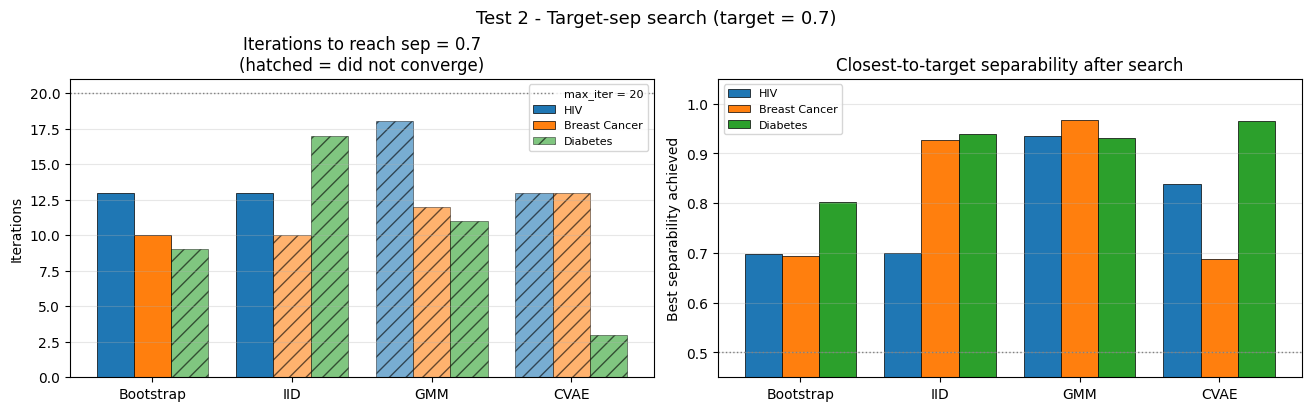

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)

datasets = list(DATASETS.keys())
x = np.arange(len(METHODS))
width = 0.8 / len(datasets)

ax = axes[0]
for i, ds in enumerate(datasets):
    sub = search_df[search_df['dataset'] == ds]
    vals = [sub[sub['method'] == m]['iterations'].values[0] for m in METHODS]
    converged = [sub[sub['method'] == m]['converged'].values[0] for m in METHODS]
    bars = ax.bar(x + (i - (len(datasets)-1)/2) * width, vals, width, label=ds,
                   edgecolor='black', linewidth=0.5)
    for bar, conv in zip(bars, converged):
        if not conv:
            bar.set_hatch('//')
            bar.set_alpha(0.6)
ax.set_xticks(x)
ax.set_xticklabels(METHODS)
ax.set_ylabel('Iterations')
ax.set_title(f'Iterations to reach sep = {TARGET_SEP}\n(hatched = did not converge)')
ax.axhline(MAX_ITER, color='gray', ls=':', lw=1, label=f'max_iter = {MAX_ITER}')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
for i, ds in enumerate(datasets):
    sub = search_df[search_df['dataset'] == ds]
    vals = [sub[sub['method'] == m]['final_sep'].values[0] for m in METHODS]
    ax.bar(x + (i - (len(datasets)-1)/2) * width, vals, width, label=ds,
            edgecolor='black', linewidth=0.5)
ax.axhline(0.5, color='gray', ls=':', lw=1)
ax.set_xticks(x)
ax.set_xticklabels(METHODS)
ax.set_ylabel('Best separability achieved')
ax.set_title('Closest-to-target separability after search')
ax.set_ylim(0.45, 1.05)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

fig.suptitle(f'Test 2 - Target-sep search (target = {TARGET_SEP})', fontsize=13)
plt.show()

### Interpretation

**Test 1** plots the noise -> separability response curve for each generator. Shape of the curve tells you the generator's failure mode: bootstrap starts near 0.5 and rises monotonically (noise-detectable), while GMM / CVAE / IID start high and rise from there (structurally-detectable).

**Test 2** asks the inverse question: can sigma-tuning drive each generator *to* the target? Bootstrap converges in few iterations because the curve crosses the target. GMM / CVAE / IID typically fail to converge — there is no sigma that makes them less separable than their sigma=0 baseline.

Together: AUC alone is many-to-one. Two generators can land at the same AUC for completely different reasons, and one of those reasons ("too noisy") is fixable while the other ("wrong structure") is not.